# **Práctica 10: Regresión usando Keras: Predicción - Eficiencia de autos.**

**Integrantes:**


*   Aguirre Lanto Victor Manuel
*   Gasca Fragoso Pedro
*   Guevara Badillo Areli Alejandra
*   Montiel Toro Arael de Jesús
*   Ramírez Lozano Gael Martin







## Importar la librerías necesarias

In [ ]:
from __future__ import absolute_import, division, print_function

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print(tf.__version__)

2.19.0


## Lectura de los datos

In [ ]:
dataset_path = 'auto-mpg.data'

In [ ]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(dataset_path, names=column_names,
                          na_values='?', comment='\t',
                          sep=" ", skipinitialspace=True)

dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


### Captura de los últimos 15 registros

In [ ]:
# Muestra los últimos 15 registros del DataFrame
print("Últimos 15 Registros del Dataset (tail):")
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(dataset_path, names=column_names,
                          na_values='?', comment='\t',
                          sep=" ", skipinitialspace=True)

dataset = raw_dataset.copy()
dataset.tail(15)

Últimos 15 Registros del Dataset (tail):


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
383,38.0,4,91.0,67.0,1965.0,15.0,82,3
384,32.0,4,91.0,67.0,1965.0,15.7,82,3
385,38.0,4,91.0,67.0,1995.0,16.2,82,3
386,25.0,6,181.0,110.0,2945.0,16.4,82,1
387,38.0,6,262.0,85.0,3015.0,17.0,82,1
388,26.0,4,156.0,92.0,2585.0,14.5,82,1
389,22.0,6,232.0,112.0,2835.0,14.7,82,1
390,32.0,4,144.0,96.0,2665.0,13.9,82,3
391,36.0,4,135.0,84.0,2370.0,13.0,82,1
392,27.0,4,151.0,90.0,2950.0,17.3,82,1


### Preguntas

In [ ]:
# Pregunta 1: ¿Cuántos objetos o registros hay en total?
total_registros = len(dataset)
print(f"Total de Registros (Objetos) Completos: {total_registros}")

Total de Registros (Objetos) Completos: 398


In [ ]:
# Pregunta 2: ¿Cuántas características o campos hay y cuáles son?
total_caracteristicas = len(dataset.columns)
nombres_caracteristicas = dataset.columns.tolist()

print(f"\nTotal de Características: {total_caracteristicas}")
print("Nombres de las Características:")
# Muestra la lista de características, una por línea
for i, nombre in enumerate(nombres_caracteristicas):
    print(f"  {i+1}. {nombre}")


Total de Características: 8
Nombres de las Características:
  1. MPG
  2. Cylinders
  3. Displacement
  4. Horsepower
  5. Weight
  6. Acceleration
  7. Model Year
  8. Origin


In [ ]:
# Pregunta 3: ¿Cuáles son los tipos de datos y rangos para cada característica?
print("\nTipos de Datos y Rangos (Mínimo y Máximo) por Característica:")

# Obtiene el tipo de dato para cada columna
tipos_datos = dataset.dtypes

# Calcula el mínimo y el máximo para cada columna numérica
rangos = pd.DataFrame({
    'Tipo de Dato': tipos_datos,
    'Mínimo': dataset.min(),
    'Máximo': dataset.max()
})

print(rangos)


Tipos de Datos y Rangos (Mínimo y Máximo) por Característica:
             Tipo de Dato  Mínimo  Máximo
MPG               float64     9.0    46.6
Cylinders           int64     3.0     8.0
Displacement      float64    68.0   455.0
Horsepower        float64    46.0   230.0
Weight            float64  1613.0  5140.0
Acceleration      float64     8.0    24.8
Model Year          int64    70.0    82.0
Origin              int64     1.0     3.0


## Preprocesamiento

### Detección de datos faltantes y eliminación de filas

In [ ]:
# Detecta datos faltantes (NaN) y suma cuántos hay por columna
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


In [ ]:
# Elimina todas las filas que contengan al menos un valor faltante
dataset = dataset.dropna()

### Codificación one-hot

In [ ]:
# Retira la columna 'Origin' del dataset y almacena sus valores en la variable Origin
Origin = dataset.pop('Origin')

In [ ]:
# Crea las nuevas columnas 'USA', 'Europe' y 'Japan'
# Asigna 1.0 si el valor original de Origin coincide con el código (1=USA, 2=Europe, 3=Japan), y 0.0 si no.
dataset['USA']    = (Origin == 1)*1.0
dataset['Europe'] = (Origin == 2)*1.0
dataset['Japan']  = (Origin == 3)*1.0

# Muestra el final del dataset para verificar el cambio
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,1.0,0.0,0.0


### Ejercicio: Codificación one-hot utilizando tf.keras.utils.to_categorical

In [ ]:
# 1. Ajustar los valores de Origin para que comiencen en 0
# to_categorical espera etiquetas que empiecen en 0. Como Origin tiene valores 1, 2, 3,
# restamos 1 para que sean 0, 1, 2.
origin_labels = Origin - 1

In [ ]:
# 2. Aplicar tf.keras.utils.to_categorical
# num_classes=3 es el número de categorías (USA, Europe, Japan)
origin_one_hot = tf.keras.utils.to_categorical(origin_labels, num_classes=3)

# 3. Convertir el resultado a DataFrame de Pandas para poder unirlo
origin_df = pd.DataFrame(origin_one_hot,
                         columns=['USA', 'Europe', 'Japan'],
                         index=dataset.index) # Usa el mismo índice que el dataset

# 4. Concatenar (unir) las nuevas columnas al dataset original
dataset = pd.concat([dataset.drop(columns=['Origin'], errors='ignore'), origin_df], axis=1)

# 5. Mostrar la captura de pantalla del resultado
print("Dataset después de la Codificación One-Hot con to_categorical:")
dataset.tail()

Dataset después de la Codificación One-Hot con to_categorical:


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,1.0,0.0,0.0


### Dividir el conjunto de datos de entrada en entrenamiento y pruebas

In [ ]:
# 80% para entrenamiento (frac=0.8). random_state=0 asegura que la división sea la misma cada vez.
train_dataset = dataset.sample(frac=0.8, random_state=0)

# El 20% restante se obtiene eliminando los índices del set de entrenamiento del dataset original.
test_dataset = dataset.drop(train_dataset.index)

In [ ]:
# Muestra los nombres de las columnas (o "keys") del set de entrenamiento.
train_dataset.keys()

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'USA', 'Europe', 'Japan'],
      dtype='object')

In [ ]:
# Para la captura de pantalla del Set de Entrenamiento:
print("Set de Entrenamiento (Primeras Filas):")
train_dataset.head()

Set de Entrenamiento (Primeras Filas):


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
146,28.0,4,90.0,75.0,2125.0,14.5,74,1.0,0.0,0.0
282,22.3,4,140.0,88.0,2890.0,17.3,79,1.0,0.0,0.0
69,12.0,8,350.0,160.0,4456.0,13.5,72,1.0,0.0,0.0
378,38.0,4,105.0,63.0,2125.0,14.7,82,1.0,0.0,0.0
331,33.8,4,97.0,67.0,2145.0,18.0,80,0.0,0.0,1.0


In [ ]:
# Para la captura de pantalla del Set de Pruebas:
print("Set de Pruebas (Primeras Filas):")
test_dataset.head()

Set de Pruebas (Primeras Filas):


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
9,15.0,8,390.0,190.0,3850.0,8.5,70,1.0,0.0,0.0
25,10.0,8,360.0,215.0,4615.0,14.0,70,1.0,0.0,0.0
28,9.0,8,304.0,193.0,4732.0,18.5,70,1.0,0.0,0.0
31,25.0,4,113.0,95.0,2228.0,14.0,71,0.0,0.0,1.0
33,19.0,6,232.0,100.0,2634.0,13.0,71,1.0,0.0,0.0


### Descriptivo de los datos

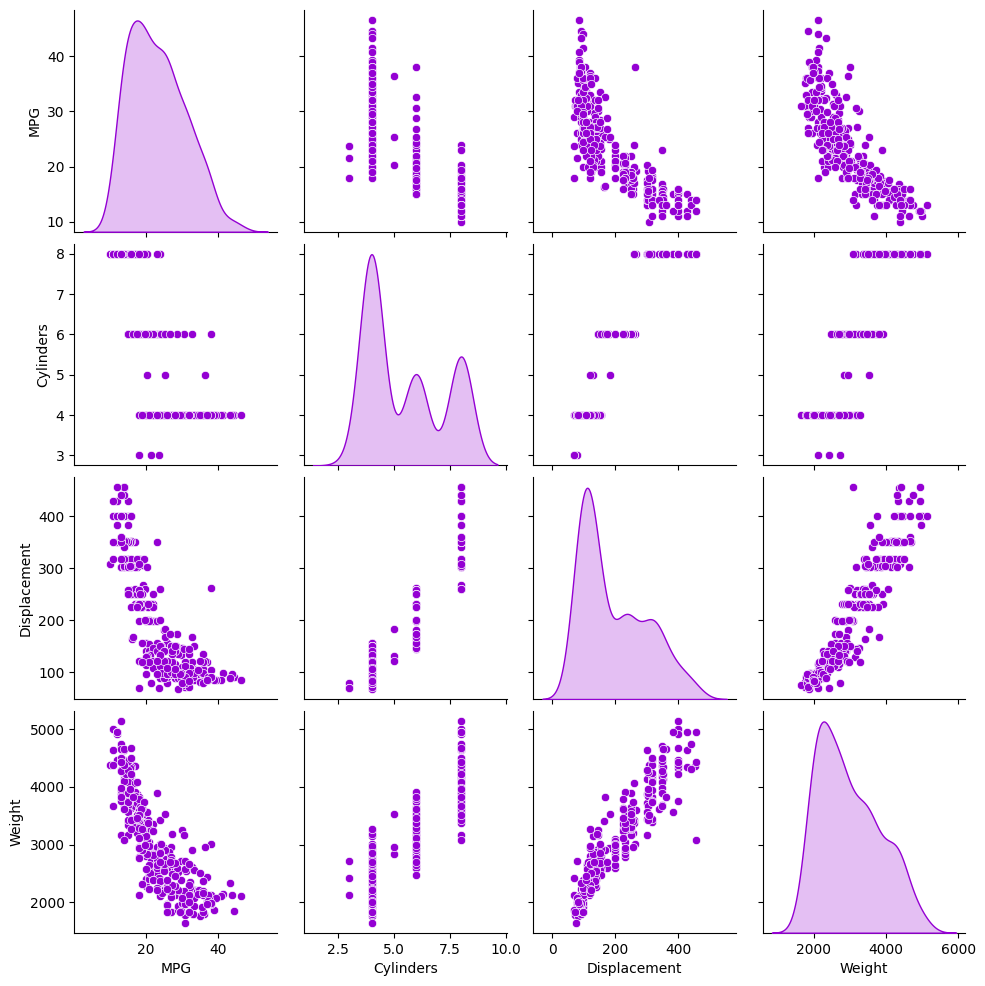

In [ ]:
purple_color = 'darkviolet'

# Revisa la distribución conjunta de las columnas especificadas en el set de entrenamiento
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde", diag_kws={'color': purple_color}, plot_kws={'color': purple_color})

### Estadísticas Generales

In [ ]:
# Calcula las estadísticas descriptivas (conteo, media, desviación estándar, min, max, cuartiles)
train_stats = train_dataset.describe()

# Elimina la fila (o columna, en el DataFrame original) 'MPG' de las estadísticas descriptivas
train_stats.pop("MPG")

# Transpone el DataFrame (cambia filas por columnas) para una mejor visualización
train_stats = train_stats.transpose()

# Muestra el resultado final (la tabla de estadísticas)
train_stats

,count,mean,std,min,25%,50%,75%,max
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0


### Separar características y etiquetas

In [ ]:
# Separa el valor objetivo ('MPG') del set de entrenamiento y lo guarda en train_labels
train_labels = train_dataset.pop('MPG')

# Separa el valor objetivo ('MPG') del set de prueba y lo guarda en test_labels
test_labels = test_dataset.pop('MPG')

In [ ]:
# 1. Recalcula las estadísticas descriptivas solo de las características restantes
train_stats = train_dataset.describe()

# 2. Transpone el DataFrame (gira filas y columnas) para facilitar la lectura de los rangos
train_stats = train_stats.transpose()

# 3. Muestra la tabla
print("Estadísticas Descriptivas del Set de Entrenamiento (Características):")
train_stats

Estadísticas Descriptivas del Set de Entrenamiento (Características):


,count,mean,std,min,25%,50%,75%,max
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0


### Normalizar los datos

In [ ]:
def norm(x):
  # Fórmula de estandarización: (valor - media) / desviación estándar
  return (x - train_stats['mean']) / train_stats['std']

# Aplica la normalización al set de entrenamiento
normed_train_data = norm(train_dataset)

# Aplica la normalización al set de pruebas (usando las estadísticas del set de entrenamiento)
normed_test_data = norm(test_dataset)

## Construir el modelo Sequential modo 1

In [ ]:
model = keras.Sequential([
  # Primera capa oculta: 64 neuronas, activación ReLU
  layers.Dense(64, activation='relu', input_shape=[normed_train_data.shape[1]]),

  # Segunda capa oculta: 64 neuronas, activación ReLU
  layers.Dense(64, activation='relu'),

  # Capa de salida: 1 neurona (para predecir el valor continuo de MPG)
  layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compilar

In [ ]:
# Define el optimizador RMSprop con una tasa de aprendizaje de 0.001
optimizer = tf.keras.optimizers.RMSprop(0.001)

# Compila el modelo
model.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae', 'mse'])

### Resumen

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

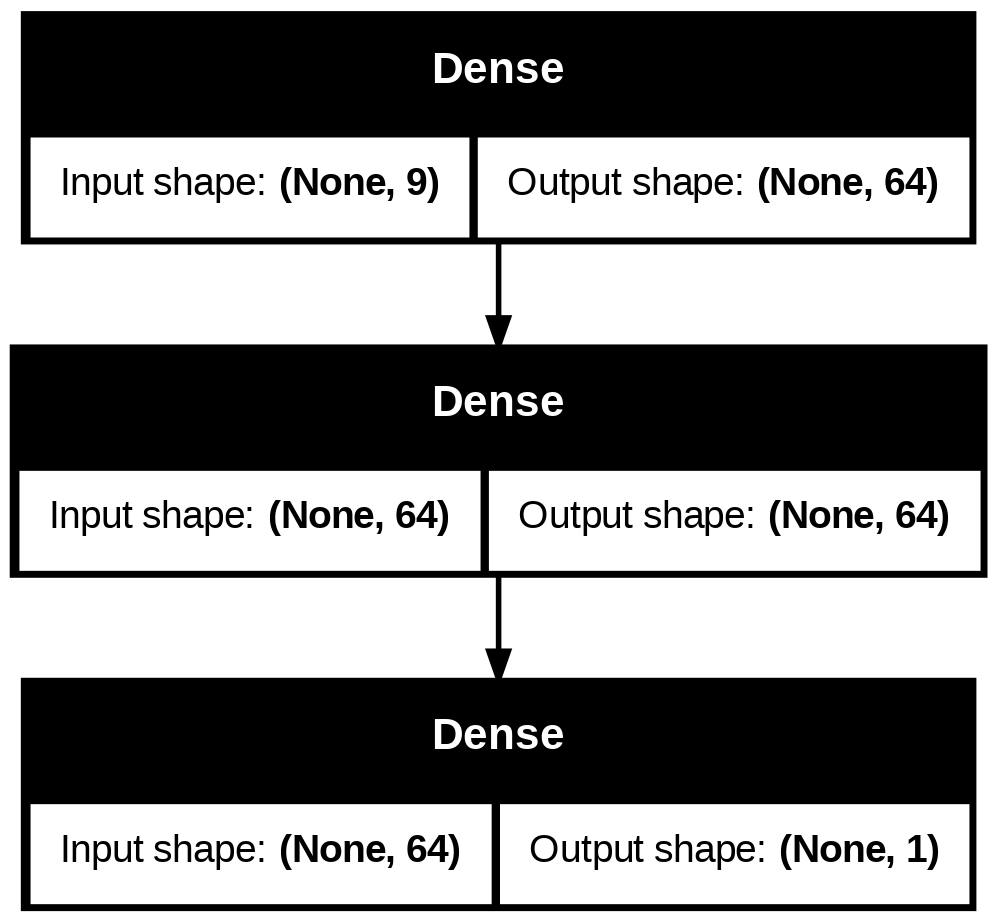

In [ ]:
# Muestra el resumen de la arquitectura del modelo (capas, forma de salida, número de parámetros)
model.summary()

# Genera un diagrama del modelo y lo guarda como una imagen PNG
# show_shapes=True incluye el tamaño de entrada y salida para cada capa
plot_model(model, to_file='gasolina_model.png', show_shapes=True)

## Entrenamiento

In [ ]:
# Define un callback personalizado para imprimir un punto al final de cada época
class PrintDot(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

epochs = 1000

# Entrena el modelo
history = model.fit(
    normed_train_data, # Datos de entrenamiento normalizados
    train_labels,      # Etiquetas de entrenamiento (MPG)
    epochs=epochs,
    validation_split = 0.2, # Usa 20% de los datos de entrenamiento para validación
    verbose=0,              # Desactiva la salida verbosa (se usa el callback)
    callbacks=[PrintDot()] # Usa el callback para imprimir los puntos
)


....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
..........................................................................................

### Visualización del progreso de entrenamiento del modelo

In [ ]:
# Convierte el historial en un DataFrame de Pandas
hist = pd.DataFrame(history.history)

# Agrega la columna de la época
hist['epoch'] = history.epoch

# Muestra el final del historial (últimas 5 épocas)
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
995,2.412328,0.984155,2.412328,8.692654,2.269777,8.692654,995
996,2.250205,0.925681,2.250205,8.680770,2.198653,8.680770,996
997,2.444779,0.977118,2.444779,8.746357,2.248545,8.746357,997
998,2.510948,0.981394,2.510948,8.633473,2.198981,8.633473,998
999,2.595410,1.030003,2.595410,8.507341,2.212317,8.507341,999


#### Visualización de los últimos 20 registros

In [ ]:
# Muestra los últimos 20 registros del historial (más que el defecto de 5)
print("Historial de Entrenamiento (Últimos 20 Registros):")
hist.tail(20)

Historial de Entrenamiento (Últimos 20 Registros):


,loss,mae,mse,val_loss,val_mae,val_mse,epoch
980,2.427131,0.968368,2.427131,8.605676,2.216807,8.605676,980
981,2.384685,0.990441,2.384685,8.625734,2.187804,8.625734,981
982,2.412498,1.011115,2.412498,8.494042,2.229594,8.494042,982
983,2.363090,0.971833,2.363090,8.764890,2.192778,8.764890,983
984,2.358644,0.966487,2.358644,8.741637,2.217512,8.741637,984
985,2.535375,1.017789,2.535375,9.395039,2.245634,9.395039,985
986,2.445359,1.018469,2.445359,8.798790,2.270952,8.798790,986
987,2.382362,1.007789,2.382362,8.785850,2.290045,8.785850,987
988,2.295995,0.954123,2.295995,9.312853,2.387461,9.312853,988
989,2.525377,1.022773,2.525377,9.279937,2.345800,9.279937,989


#### Visualización de las Gráficas de Aprendizaje

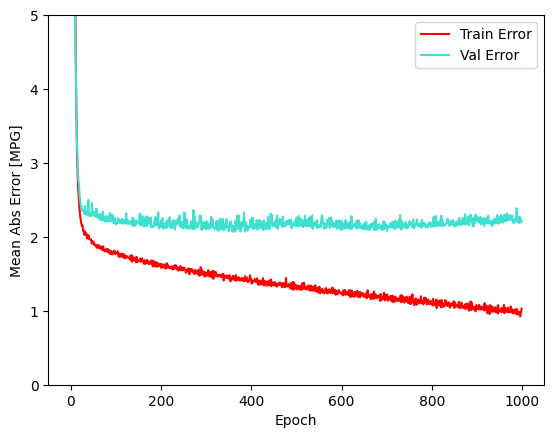

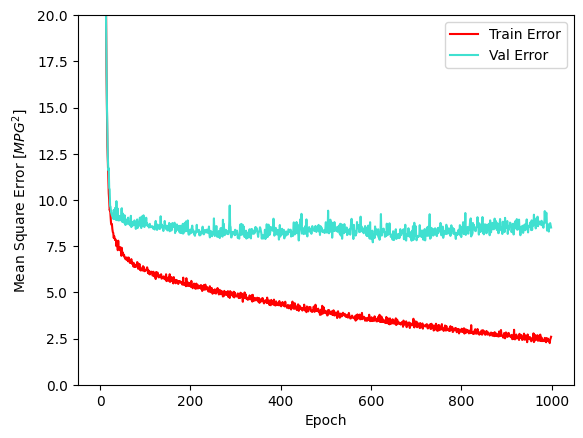

In [ ]:
def plot_history(history):
  # Convierte el historial en un DataFrame de Pandas
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  # --- Gráfico 1: Error Absoluto Medio (MAE) ---
  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [MPG]')

  # Gráfica del MAE de entrenamiento
  plt.plot(hist['epoch'], hist['mae'], label='Train Error', color='red')

  # Gráfica del MAE de validación
  plt.plot(hist['epoch'], hist['val_mae'], label='Val Error', color='turquoise')

  # Limita el eje Y entre 0 y 5
  plt.ylim([0, 5])
  plt.legend()

  # --- Gráfico 2: Error Cuadrático Medio (MSE) ---
  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [$MPG^2$]')

  # Gráfica del MSE de entrenamiento
  plt.plot(hist['epoch'], hist['mse'], label='Train Error', color='red')

  # Gráfica del MSE de validación
  plt.plot(hist['epoch'], hist['val_mse'], label='Val Error', color='turquoise')

  # Limita el eje Y entre 0 y 20
  plt.ylim([0, 20])
  plt.legend()

  # Muestra ambos gráficos
  plt.show()

# Ejecución de la función
plot_history(history)

#### Visualización de la gráficas usando EarlyStopping


.............

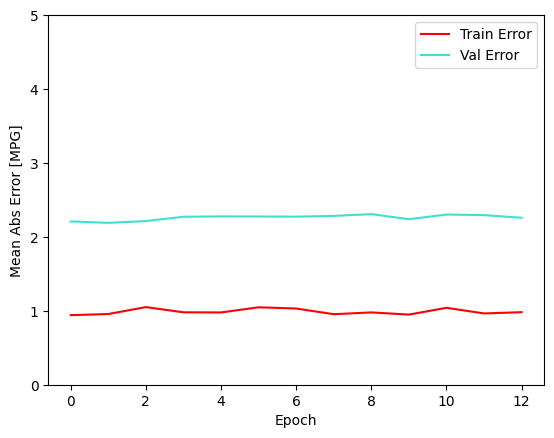

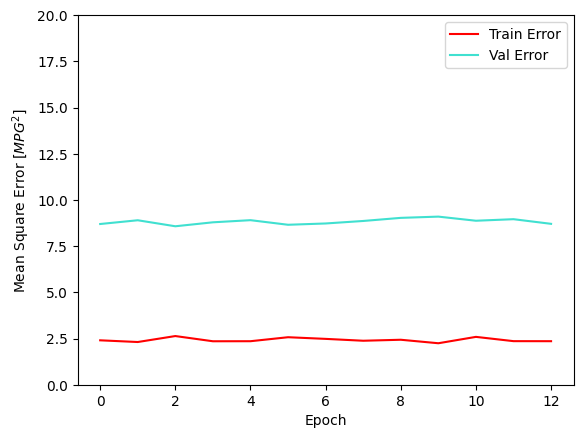

In [ ]:
# Se define EarlyStopping: monitorea la pérdida de validación ('val_loss')
# y detiene el entrenamiento si no hay mejora durante 10 épocas ('patience=10').
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Se vuelve a entrenar el modelo, ahora con el callback EarlyStopping
history = model.fit(normed_train_data, train_labels, epochs=epochs,
                    validation_split = 0.2, verbose=0,
                    callbacks=[early_stop, PrintDot()])

# Visualiza el historial del nuevo entrenamiento
plot_history(history)

##  Generalización del modelo al usar el conjunto test

In [ ]:
# Evalúa el modelo en el conjunto de prueba
loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=2)

# Imprime el Error Absoluto Medio (MAE)
print(f"Testing set Mean Abs Error: {mae:5.2f} MPG".format(mae))

3/3 - 0s - 15ms/step - loss: 4.9072 - mae: 1.7363 - mse: 4.9072
Testing set Mean Abs Error:  1.74 MPG


### Predicciones

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


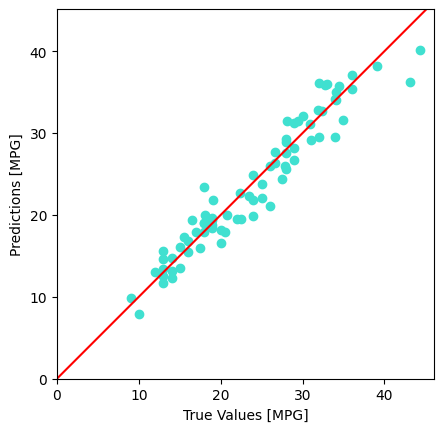

In [ ]:
# Genera las predicciones usando el set de prueba normalizado
test_predictions = model.predict(normed_test_data).flatten()

# --- Creación del Gráfico ---
plt.scatter(test_labels, test_predictions, color='turquoise')
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal') # Asegura que la escala de los ejes sea la misma
plt.axis('square') # Asegura que el área del gráfico sea cuadrada

# Definir límites para los ejes X e Y basados en los valores presentes en el set de prueba
# Esto asegura que el gráfico se centre en el rango de los datos
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])

# Dibujar la línea diagonal y=x (predicciones perfectas)
_ = plt.plot([-100, 100], [-100, 100], color='red') # Cambiado a rojo para distinguirla

### Distribución de errores

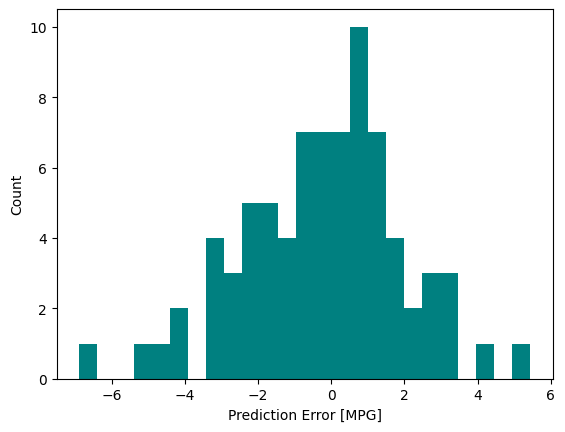

In [ ]:
# Calcula los errores de predicción
error = test_predictions - test_labels

# Crea un histograma de los errores
plt.hist(error, bins=25, color='teal')
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")